# CC Calls — Exploratory Data Analysis
Target variable derived from `Prospect_Outcome` in billings

## 0. Imports & Merged Data (Your Existing Code)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import os
from scipy.stats import pointbiserialr

# ── YOUR EXISTING CODE ───────────────────────────────────────────────────────
cc_calls    = pd.read_csv('../../dataset/02_basic_clean/cc_calls.csv')
billings_df = pd.read_csv('../../dataset/02_basic_clean/billings.csv')

billings_df = billings_df[['Co_Ref', 'Prospect_Renewal_Date', 'Prospect_Outcome']]

cc_calls['Call_Date']                = pd.to_datetime(cc_calls['Call_Date'],                dayfirst=True)
billings_df['Prospect_Renewal_Date'] = pd.to_datetime(billings_df['Prospect_Renewal_Date'], dayfirst=True)

merged_cc_calls = cc_calls.merge(billings_df, on='Co_Ref', how='inner')

merged_cc_calls['Days_Before_Renewal'] = (
    merged_cc_calls['Prospect_Renewal_Date'] - merged_cc_calls['Call_Date']
).dt.days

merged_cc_calls = merged_cc_calls[
    (merged_cc_calls['Days_Before_Renewal'] >= 14) &
    (merged_cc_calls['Days_Before_Renewal'] <= 45)
]

rows_to_drop = merged_cc_calls[merged_cc_calls['Prospect_Outcome'] == 'Open'].index
merged_cc_calls.drop(rows_to_drop, inplace=True)

merged_cc_calls = merged_cc_calls.sort_values(
    by=['Co_Ref', 'Call_Date'], ascending=[True, True]
)
# ─────────────────────────────────────────────────────────────────────────────

print('Shape after merge + filter:', merged_cc_calls.shape)
print('Prospect_Outcome counts:')
print(merged_cc_calls['Prospect_Outcome'].value_counts())

C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_10648\1676028381.py:11: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  billings_df = pd.read_csv('../../dataset/02_basic_clean/billings.csv')


Shape after merge + filter: (4117, 36)
Prospect_Outcome counts:
Prospect_Outcome
Won        3815
Churned     302
Name: count, dtype: int64


In [ ]:
# import pandas as pd

# # ── SAMPLE DATA ─────────────────────────────────────────────────────
# billings_df = pd.DataFrame({
#     'Co_Ref': ['A', 'A'],
#     'Prospect_Renewal_Date': ['12-01-2025', '12-01-2026']
# })

# renewal_calls = pd.DataFrame({
#     'Co_Ref': ['A','A','A','A','A','A'],
#     'Call_Date': [
#         '19-12-2024',
#         '20-12-2024',
#         '21-12-2024',
#         '19-12-2025',
#         '19-12-2025',
#         '19-12-2025'
#     ]
# })

# # ── CONVERT DATES ───────────────────────────────────────────────────
# billings_df['Prospect_Renewal_Date'] = pd.to_datetime(
#     billings_df['Prospect_Renewal_Date'], dayfirst=True
# )

# renewal_calls['Call_Date'] = pd.to_datetime(
#     renewal_calls['Call_Date'], dayfirst=True
# )

# # ── MERGE ───────────────────────────────────────────────────────────
# merged = billings_df.merge(renewal_calls, on='Co_Ref', how='left')

# # Keep only calls BEFORE renewal
# merged = merged[
#     (merged['Call_Date'].isna()) |
#     (merged['Call_Date'] <= merged['Prospect_Renewal_Date'])
# ]

# # Days before renewal
# merged['Days_Before_Renewal'] = (
#     merged['Prospect_Renewal_Date'] - merged['Call_Date']
# ).dt.days

# # Flag 14–45 calls
# merged['renewal_14_45_flag'] = (
#     (merged['Days_Before_Renewal'] >= 14) &
#     (merged['Days_Before_Renewal'] <= 45)
# ).astype(int)

# # ✅ FIX: GROUP BY BOTH
# agg_calls = merged.groupby(
#     ['Co_Ref', 'Prospect_Renewal_Date']
# ).agg(
#     renewal_call_count_14_45=('renewal_14_45_flag', 'sum')

# ).reset_index()

# # ── MERGE BACK ──────────────────────────────────────────────────────
# final_df = billings_df.merge(
#     agg_calls,
#     on=['Co_Ref', 'Prospect_Renewal_Date'],
#     how='left'
# )

# final_df['renewal_call_count_14_45'] = final_df['renewal_call_count_14_45'].fillna(0)

# print(final_df)

  Co_Ref Prospect_Renewal_Date  renewal_call_count_14_45
0      A            2025-01-12                         3
1      A            2026-01-12                         3


In [ ]:
cc_calls.shape[0]

32789

---
## 1. Create Target Column

In [2]:
# Encode: 1 = Churned, 0 = Renewed
merged_cc_calls['target'] = (merged_cc_calls['Prospect_Outcome'].str.strip() == 'Churned').astype(int)

# Work on a clean copy; keep backup for column-diff tracking later
df        = merged_cc_calls.copy()
df_backup = df.copy()

print('Target encoding (0=Renewed, 1=Churned):')
print(df['target'].value_counts())
print()
print('Percentage split:')
print((df['target'].value_counts(normalize=True) * 100).round(2))
print()
print('Working dataframe shape:', df.shape)

Target encoding (0=Renewed, 1=Churned):
target
0    3815
1     302
Name: count, dtype: int64

Percentage split:
target
0    92.66
1     7.34
Name: proportion, dtype: float64

Working dataframe shape: (4117, 37)


---
## 2. Target Variable Analysis

C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_9504\651376886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4C9BE8', '#E8604C'], ax=ax)


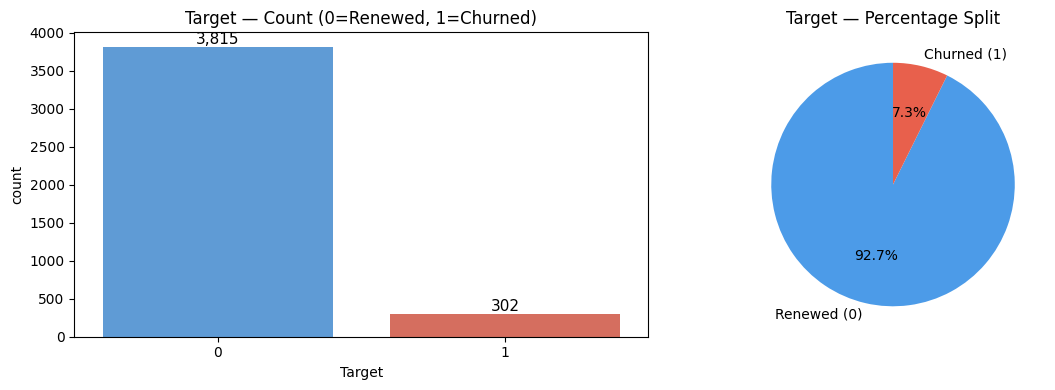

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
ax = axes[0]
sns.countplot(x='target', data=df, palette=['#4C9BE8', '#E8604C'], ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_title('Target — Count (0=Renewed, 1=Churned)')
ax.set_xlabel('Target')

# Pie chart
counts = df['target'].value_counts()
axes[1].pie(
    counts,
    labels=['Renewed (0)', 'Churned (1)'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E8604C'],
    startangle=90
)
axes[1].set_title('Target — Percentage Split')

plt.tight_layout()
plt.show()

In [4]:
# Class imbalance check
majority = counts.max()
minority = counts.min()
ratio    = majority / minority

print(f'Imbalance ratio: {ratio:.2f}:1')
if ratio > 3:
    print('⚠️  Highly imbalanced — consider SMOTE or class_weight="balanced" when modelling')
elif ratio > 1.5:
    print('⚠️  Moderately imbalanced — monitor precision/recall carefully')
else:
    print('✅ Reasonably balanced')

Imbalance ratio: 12.63:1
⚠️  Highly imbalanced — consider SMOTE or class_weight="balanced" when modelling


In [5]:
# Missing values in target
print('Missing in target:', df['target'].isnull().sum())
print('Missing %:',         df['target'].isnull().mean() * 100)

df = df.dropna(subset=['target'])
print('Remaining rows after dropping missing target:', len(df))

Missing in target: 0
Missing %: 0.0
Remaining rows after dropping missing target: 4117


---
## 3. Column Overview

In [6]:
print(df.columns)

Index(['Contact_ID', 'Call_Date', 'Direction', 'cc_care_package',
       'cc_care_package_discussed', 'cc_urgency_getting_on_site',
       'cc_external_consultant', 'cc_agent_cross_sell_attempt',
       'cc_customer_issues_concerns',
       'cc_business_struggles_financial_hardship', 'cc_call_initiated_by',
       'cc_questionnaire_completion', 'cc_chasing_response',
       'cc_issues_within_questionnaire', 'cc_login_issues',
       'cc_platform_issues', 'cc_dissatisfaction_time_to_complete',
       'cc_process_complexity_concerns', 'cc_questions_harder_than_expected',
       'cc_dissatisfaction_support', 'cc_contractor_sentiment',
       'cc_contractor_sentiment_start_score',
       'cc_contractor_sentiment_end_score',
       'cc_contractor_sentiment_overall_score',
       'cc_contractor_sentiment_issues_score', 'cc_pricing_mentioned',
       'cc_pricing_sentiment_impact', 'cc_refund_discussed',
       'cc_contractor_suggest_leave', 'cc_contractor_complained', 'Co_Ref',
       'Analys

In [7]:
# Columns to always exclude from analysis
EXCLUDE_COLS = [
    'Co_Ref', 'Contact_ID', 'Call_Date', 'Analysed_Call',
    'Prospect_Renewal_Date', 'Prospect_Outcome', 'target'
]

numerical_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if col not in EXCLUDE_COLS
]

cat_cols = [
    col for col in df.select_dtypes(include=['object', 'category']).columns
    if col not in EXCLUDE_COLS
]

print(f'Numerical columns  ({len(numerical_cols)}): {numerical_cols}')
print()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns  (2): ['Call_Year', 'Days_Before_Renewal']

Categorical columns (28): ['Direction', 'cc_care_package', 'cc_care_package_discussed', 'cc_urgency_getting_on_site', 'cc_external_consultant', 'cc_agent_cross_sell_attempt', 'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship', 'cc_call_initiated_by', 'cc_questionnaire_completion', 'cc_chasing_response', 'cc_issues_within_questionnaire', 'cc_login_issues', 'cc_platform_issues', 'cc_dissatisfaction_time_to_complete', 'cc_process_complexity_concerns', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score', 'cc_contractor_sentiment_issues_score', 'cc_pricing_mentioned', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_suggest_leave', 'cc_contractor_complained']


C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_9504\2435699728.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include=['object', 'category']).columns


In [8]:
# Low-cardinality numerical columns that may actually be categorical
print('Numerical columns with < 15 unique values (consider treating as categorical):')
for col in numerical_cols:
    n = df[col].nunique()
    if n < 15:
        print(f'  {col} → {n} unique values: {sorted(df[col].dropna().unique().tolist())}')

Numerical columns with < 15 unique values (consider treating as categorical):
  Call_Year → 3 unique values: [2024, 2025, 2026]


In [9]:
# TAKE DECISION ── move any low-cardinality columns from numerical to categorical
# Example:
# low_card = ['cc_contractor_sentiment_start_score']   # add as needed
# cat_cols      += low_card
# numerical_cols = [c for c in numerical_cols if c not in low_card]

print('Final numerical_cols:', numerical_cols)
print('Final cat_cols      :', cat_cols)

Final numerical_cols: ['Call_Year', 'Days_Before_Renewal']
Final cat_cols      : ['Direction', 'cc_care_package', 'cc_care_package_discussed', 'cc_urgency_getting_on_site', 'cc_external_consultant', 'cc_agent_cross_sell_attempt', 'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship', 'cc_call_initiated_by', 'cc_questionnaire_completion', 'cc_chasing_response', 'cc_issues_within_questionnaire', 'cc_login_issues', 'cc_platform_issues', 'cc_dissatisfaction_time_to_complete', 'cc_process_complexity_concerns', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score', 'cc_contractor_sentiment_issues_score', 'cc_pricing_mentioned', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_suggest_leave', 'cc_contractor_complained']


In [10]:
# Summary statistics
summary = df[numerical_cols].describe().T
summary['skewness']  = df[numerical_cols].skew().round(2)
summary['missing_%'] = (df[numerical_cols].isna().mean() * 100).round(2)
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,missing_%
Call_Year,4117.0,2024.94,0.32,2024.0,2025.0,2025.0,2025.0,2026.0,-1.19,0.0
Days_Before_Renewal,4117.0,29.02,9.22,14.0,21.0,29.0,37.0,45.0,0.08,0.0


---
## 4. Univariate Analysis — Numerical

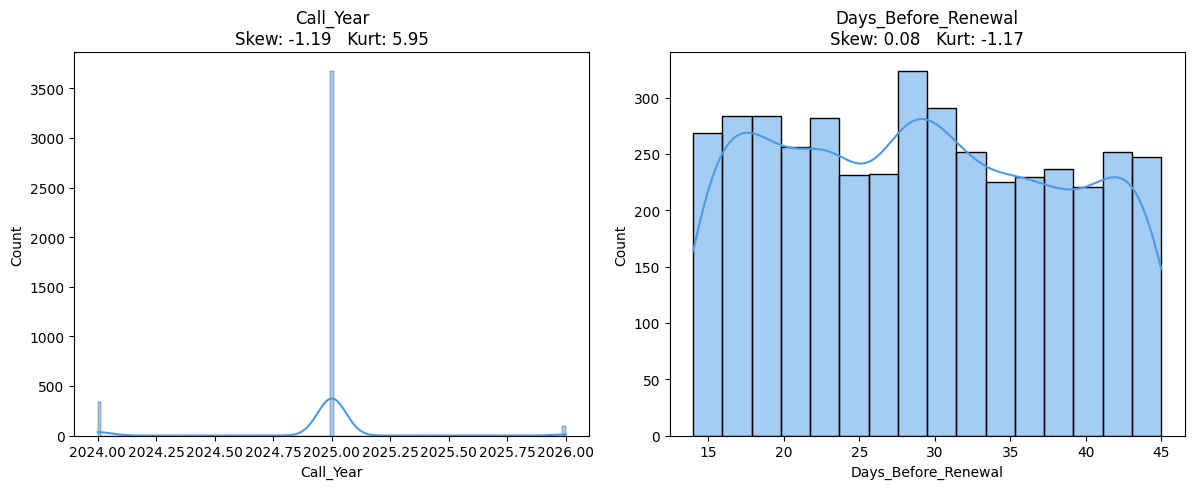

In [11]:
# Distribution histograms with skew + kurtosis
if numerical_cols:
    n_cols_plot = 3
    n_rows_plot = math.ceil(len(numerical_cols) / n_cols_plot)

    plt.figure(figsize=(18, 5 * n_rows_plot))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows_plot, n_cols_plot, i)
        sns.histplot(df[col].dropna(), kde=True, color='#4C9BE8')
        skew = df[col].skew()
        kurt = df[col].kurtosis()
        plt.title(f'{col}\nSkew: {skew:.2f}   Kurt: {kurt:.2f}')
    plt.tight_layout()
    plt.show()
else:
    print('No numerical columns found.')

In [12]:
# Skewness summary table
# Reference: |skew| < 0.5 = Normal ✅ | 0.5–1 = Moderate ⚠️ | > 1 = High 🔥
dist_summary = []
for col in numerical_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    skew_type = (
        '✅ Normal'     if abs(skew) < 0.5 else
        '⚠️  Moderate'  if abs(skew) < 1   else
        '🔥 High'
    )
    dist_summary.append({'column': col, 'skewness': round(skew, 2),
                         'kurtosis': round(kurt, 2), 'skew_type': skew_type})

dist_df = pd.DataFrame(dist_summary).sort_values('skewness', ascending=False)
dist_df

,column,skewness,kurtosis,skew_type
1,Days_Before_Renewal,0.08,-1.17,✅ Normal
0,Call_Year,-1.19,5.95,🔥 High


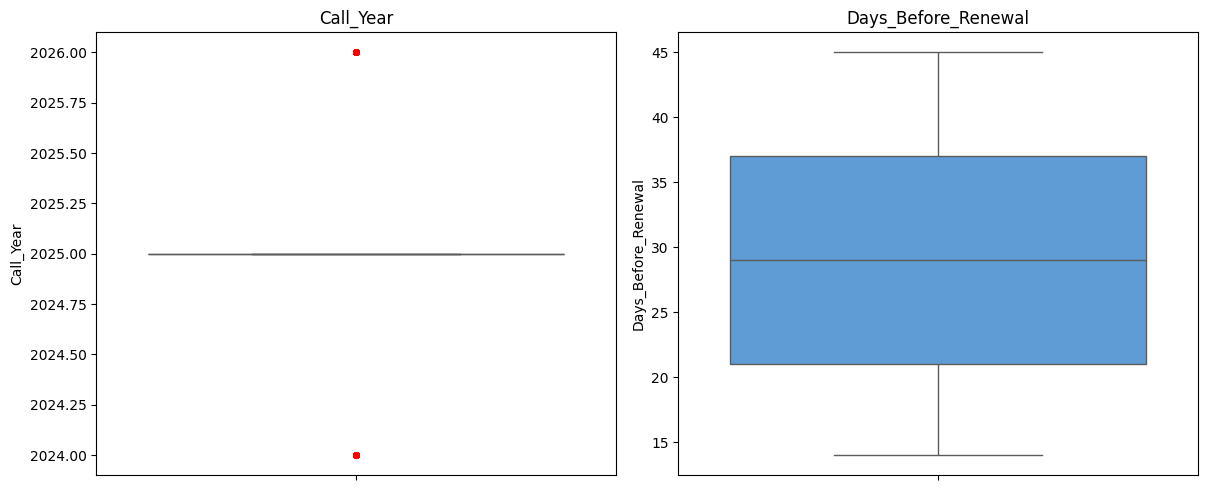

In [13]:
# Outlier detection — boxplots
if numerical_cols:
    n_cols_plot = 3
    n_rows_plot = math.ceil(len(numerical_cols) / n_cols_plot)

    plt.figure(figsize=(18, 5 * n_rows_plot))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows_plot, n_cols_plot, i)
        sns.boxplot(
            y=df[col], color='#4C9BE8',
            flierprops=dict(marker='o', markerfacecolor='red',
                            markeredgecolor='red', markersize=4)
        )
        plt.title(col)
    plt.tight_layout()
    plt.show()

In [14]:
# Outlier count table using IQR method
outlier_summary = []
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({
        'column': col,
        'outlier_count': n_out,
        'outlier_%': round(n_out / len(df) * 100, 2),
        'lower_bound': round(lo, 2),
        'upper_bound': round(hi, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_%', ascending=False)
outlier_df

,column,outlier_count,outlier_%,lower_bound,upper_bound
0,Call_Year,439,10.66,2025.0,2025.0
1,Days_Before_Renewal,0,0.00,-3.0,61.0


In [15]:
# TAKE DECISION ── cap outliers for columns where outlier_% > 5
# Option A: Cap at 99th percentile
# Option B: Log-transform (use when skew > 1)

# cols_to_cap = outlier_df[outlier_df['outlier_%'] > 5]['column'].tolist()
# for col in cols_to_cap:
#     upper_cap = df[col].quantile(0.99)
#     df[col]   = df[col].clip(upper=upper_cap)
#     print(f'Capped  {col}  at  {upper_cap:.2f}')

# cols_to_log = [c for c in cols_to_cap if df[c].skew() > 1]
# for col in cols_to_log:
#     df[col] = np.log1p(df[col])
#     print(f'Log-transformed  {col}')

print('Outlier treatment: review outlier_df above, then uncomment the relevant block')

Outlier treatment: review outlier_df above, then uncomment the relevant block


In [16]:
# Zero, constant, and negative value checks
eda_checks = []
for col in numerical_cols:
    eda_checks.append({
        'column':         col,
        'zero_%':         round((df[col] == 0).mean() * 100, 2),
        'unique_values':  df[col].nunique(),
        'negative_count': (df[col] < 0).sum()
    })

checks_df = pd.DataFrame(eda_checks).sort_values('zero_%', ascending=False)
checks_df

# TAKE DECISION:
# zero_% very high   → add a binary flag feature  e.g. 'has_X = (col > 0).astype(int)'
# unique_values == 1 → constant column, DROP it
# negative_count > 0 → check if valid or data error

,column,zero_%,unique_values,negative_count
0,Call_Year,0.0,3,0
1,Days_Before_Renewal,0.0,32,0


---
## 5. Univariate Analysis — Categorical

In [17]:
# Value counts summary for all categorical columns
cat_summary = []
for col in cat_cols:
    vc = df[col].value_counts(normalize=True, dropna=False)
    cat_summary.append({
        'column':        col,
        'unique_values': df[col].nunique(),
        'top_category':  vc.index[0],
        'top_%':         round(vc.iloc[0] * 100, 2),
        'missing_%':     round(df[col].isna().mean() * 100, 2)
    })

cat_summary_df = pd.DataFrame(cat_summary).sort_values('top_%', ascending=False)
cat_summary_df

,column,unique_values,top_category,top_%,missing_%
16,cc_questions_harder_than_expected,3,No,99.71,0.10
25,cc_refund_discussed,3,no,99.15,0.00
17,cc_dissatisfaction_support,3,No,97.45,0.10
14,cc_dissatisfaction_time_to_complete,3,No,96.02,0.10
5,cc_agent_cross_sell_attempt,7,No,95.90,0.44
7,cc_business_struggles_financial_hardship,3,No,95.70,0.44
12,cc_login_issues,3,No,94.92,0.10
24,cc_pricing_sentiment_impact,3,no,94.90,0.00
26,cc_contractor_suggest_leave,12,No,94.66,0.36
27,cc_contractor_complained,3,No,92.47,0.36


In [18]:
# Identify problem columns
low_var_cols  = [col for col in cat_cols
                 if df[col].value_counts(normalize=True, dropna=False).iloc[0] > 0.95]
high_card_cols = [col for col in cat_cols if df[col].nunique() > 50]

print('Low-variance columns (>95% one category) → likely DROP:')
print(low_var_cols)
print()
print('High-cardinality columns (>50 unique) → group or target-encode:')
print(high_card_cols)

Low-variance columns (>95% one category) → likely DROP:
['cc_agent_cross_sell_attempt', 'cc_business_struggles_financial_hardship', 'cc_dissatisfaction_time_to_complete', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_refund_discussed']

High-cardinality columns (>50 unique) → group or target-encode:
[]


In [19]:
# TAKE DECISION ── drop low-variance / high-cardinality columns if needed
# cols_to_drop = low_var_cols + high_card_cols
# df.drop(columns=cols_to_drop, inplace=True)
# cat_cols = [c for c in cat_cols if c not in cols_to_drop]

print('No columns dropped yet — review the lists above first')

No columns dropped yet — review the lists above first


C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_9504\3121289671.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


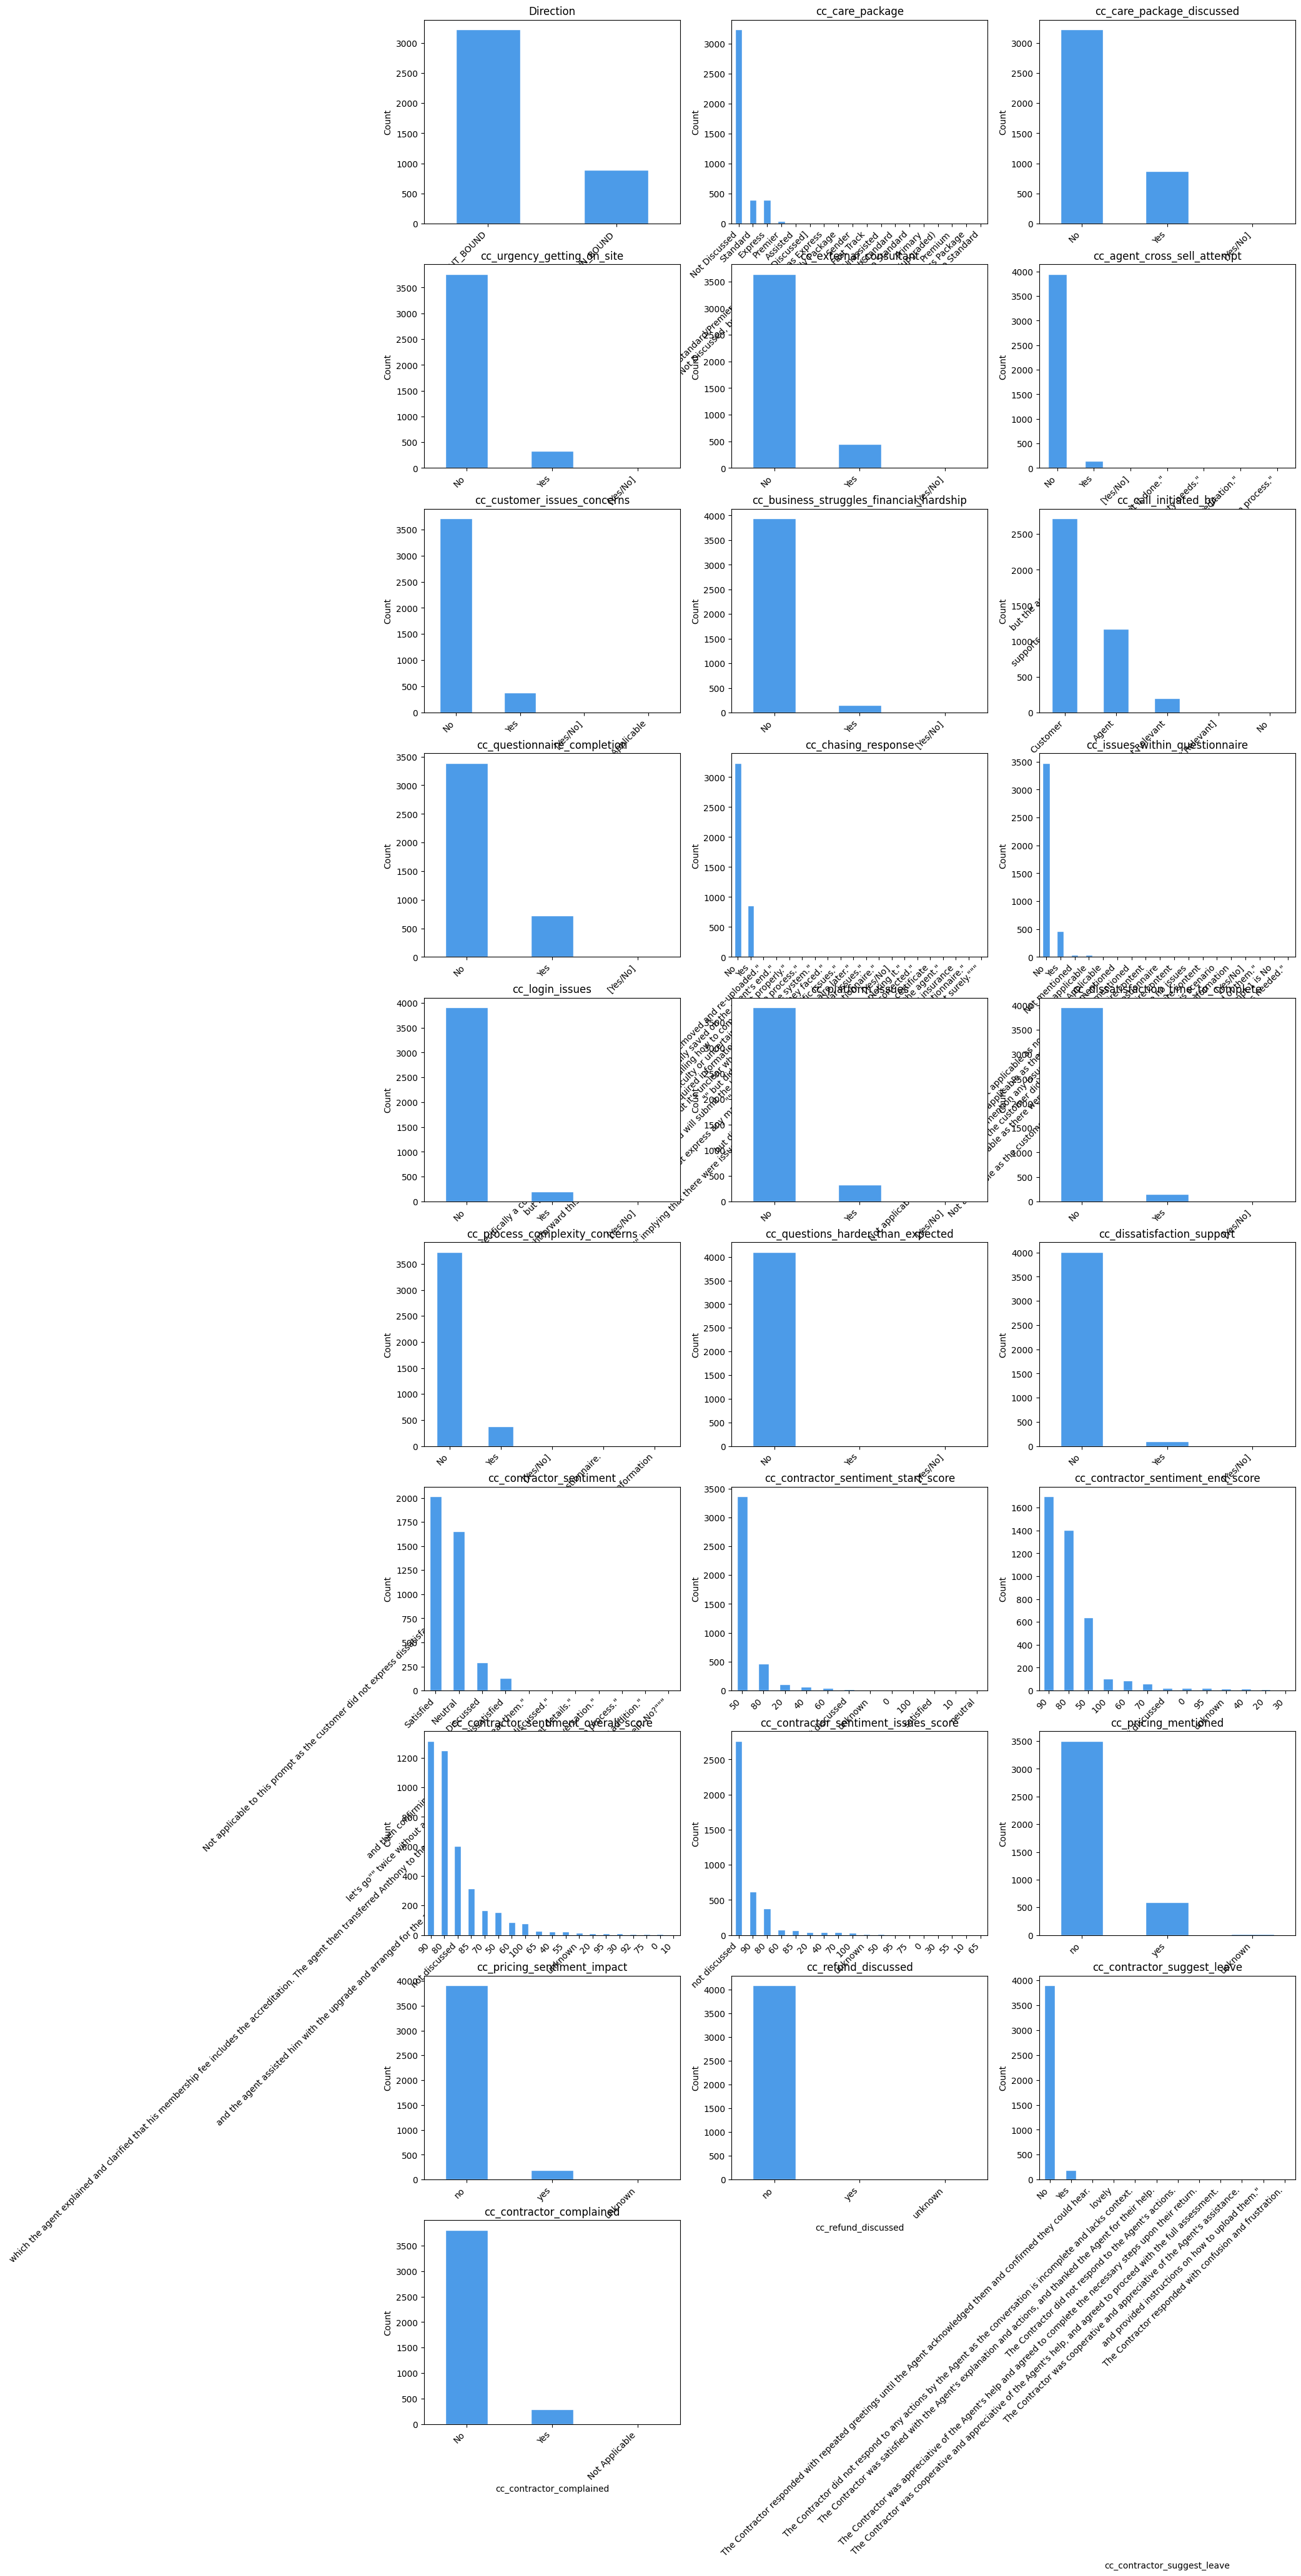

In [20]:
# Bar charts for categorical columns (max 50 unique values)
cols_to_plot = [col for col in cat_cols if df[col].nunique() <= 50]

if cols_to_plot:
    n_cols_plot = 3
    n_rows_plot = math.ceil(len(cols_to_plot) / n_cols_plot)

    plt.figure(figsize=(18, 5 * n_rows_plot))
    for i, col in enumerate(cols_to_plot, 1):
        plt.subplot(n_rows_plot, n_cols_plot, i)
        vc = df[col].value_counts().head(20)
        vc.plot(kind='bar', color='#4C9BE8', edgecolor='white')
        plt.title(col)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns with <= 50 unique values to plot')

---
## 6. Bivariate Analysis — Features vs Churn (Target)

### 6a. Numerical Features vs Churn

NameError: name 'num_cols_biv' is not defined

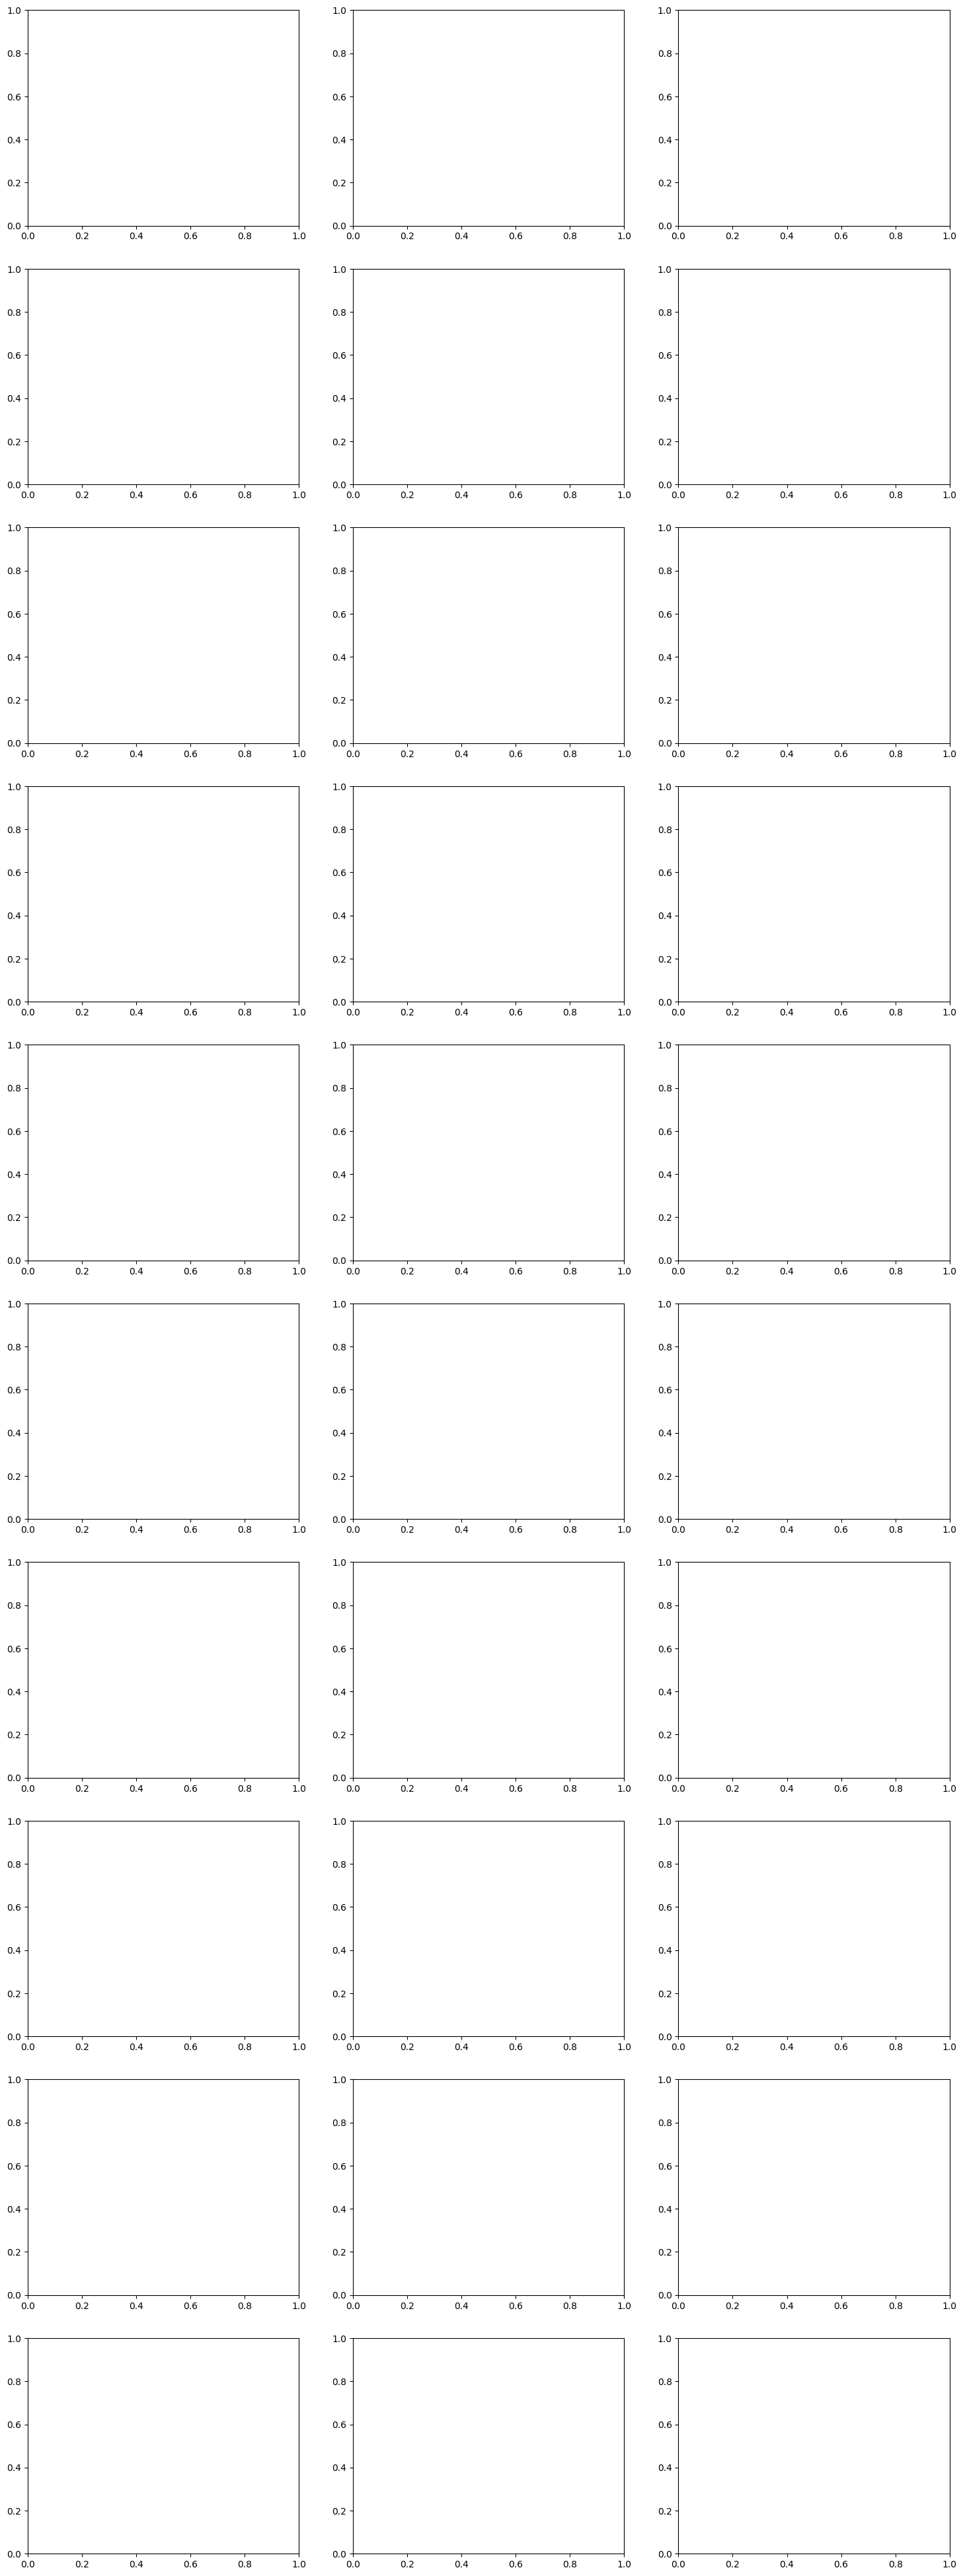

In [21]:
df['target'] = df['target'].astype(int)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols_biv):
    sns.boxplot(
        x='target',
        y=col,
        data=df,
        hue='target',          # ✅ add hue
        palette={0: '#4C9BE8', 1: '#E8604C'},
        ax=axes[i],
        legend=False           # ✅ remove duplicate legend
    )
    axes[i].set_title(f'{col} vs target')
    axes[i].set_xlabel('Target (0=Renewed, 1=Churned)')

In [ ]:
# Mean comparison table: target=0 vs target=1
mean_comparison = df.groupby('target')[num_cols_biv].mean().T.round(3)
mean_comparison.columns = ['Mean (Renewed=0)', 'Mean (Churned=1)']
mean_comparison['difference']    = (mean_comparison['Mean (Churned=1)'] - mean_comparison['Mean (Renewed=0)']).round(3)
mean_comparison['diff_%']        = ((mean_comparison['difference'] / (mean_comparison['Mean (Renewed=0)'].abs() + 1e-9)) * 100).round(1)
mean_comparison['signal_strength'] = mean_comparison['diff_%'].abs().apply(
    lambda x: '⭐⭐⭐ Strong' if x > 20 else ('⭐⭐ Moderate' if x > 10 else '⭐ Weak')
)
mean_comparison.sort_values('diff_%', ascending=False)

,Mean (Renewed=0),Mean (Churned=1),difference,diff_%,signal_strength
Call_Year,2024.833,2024.743,-0.090,-0.0,⭐ Weak
Days_Before_Renewal,28.925,27.286,-1.639,-5.7,⭐ Weak


### 6b. Categorical Features vs Churn (Churn Rate by Category)

C:\Users\Asus\AppData\Local\Temp\ipykernel_37348\3377288014.py:24: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


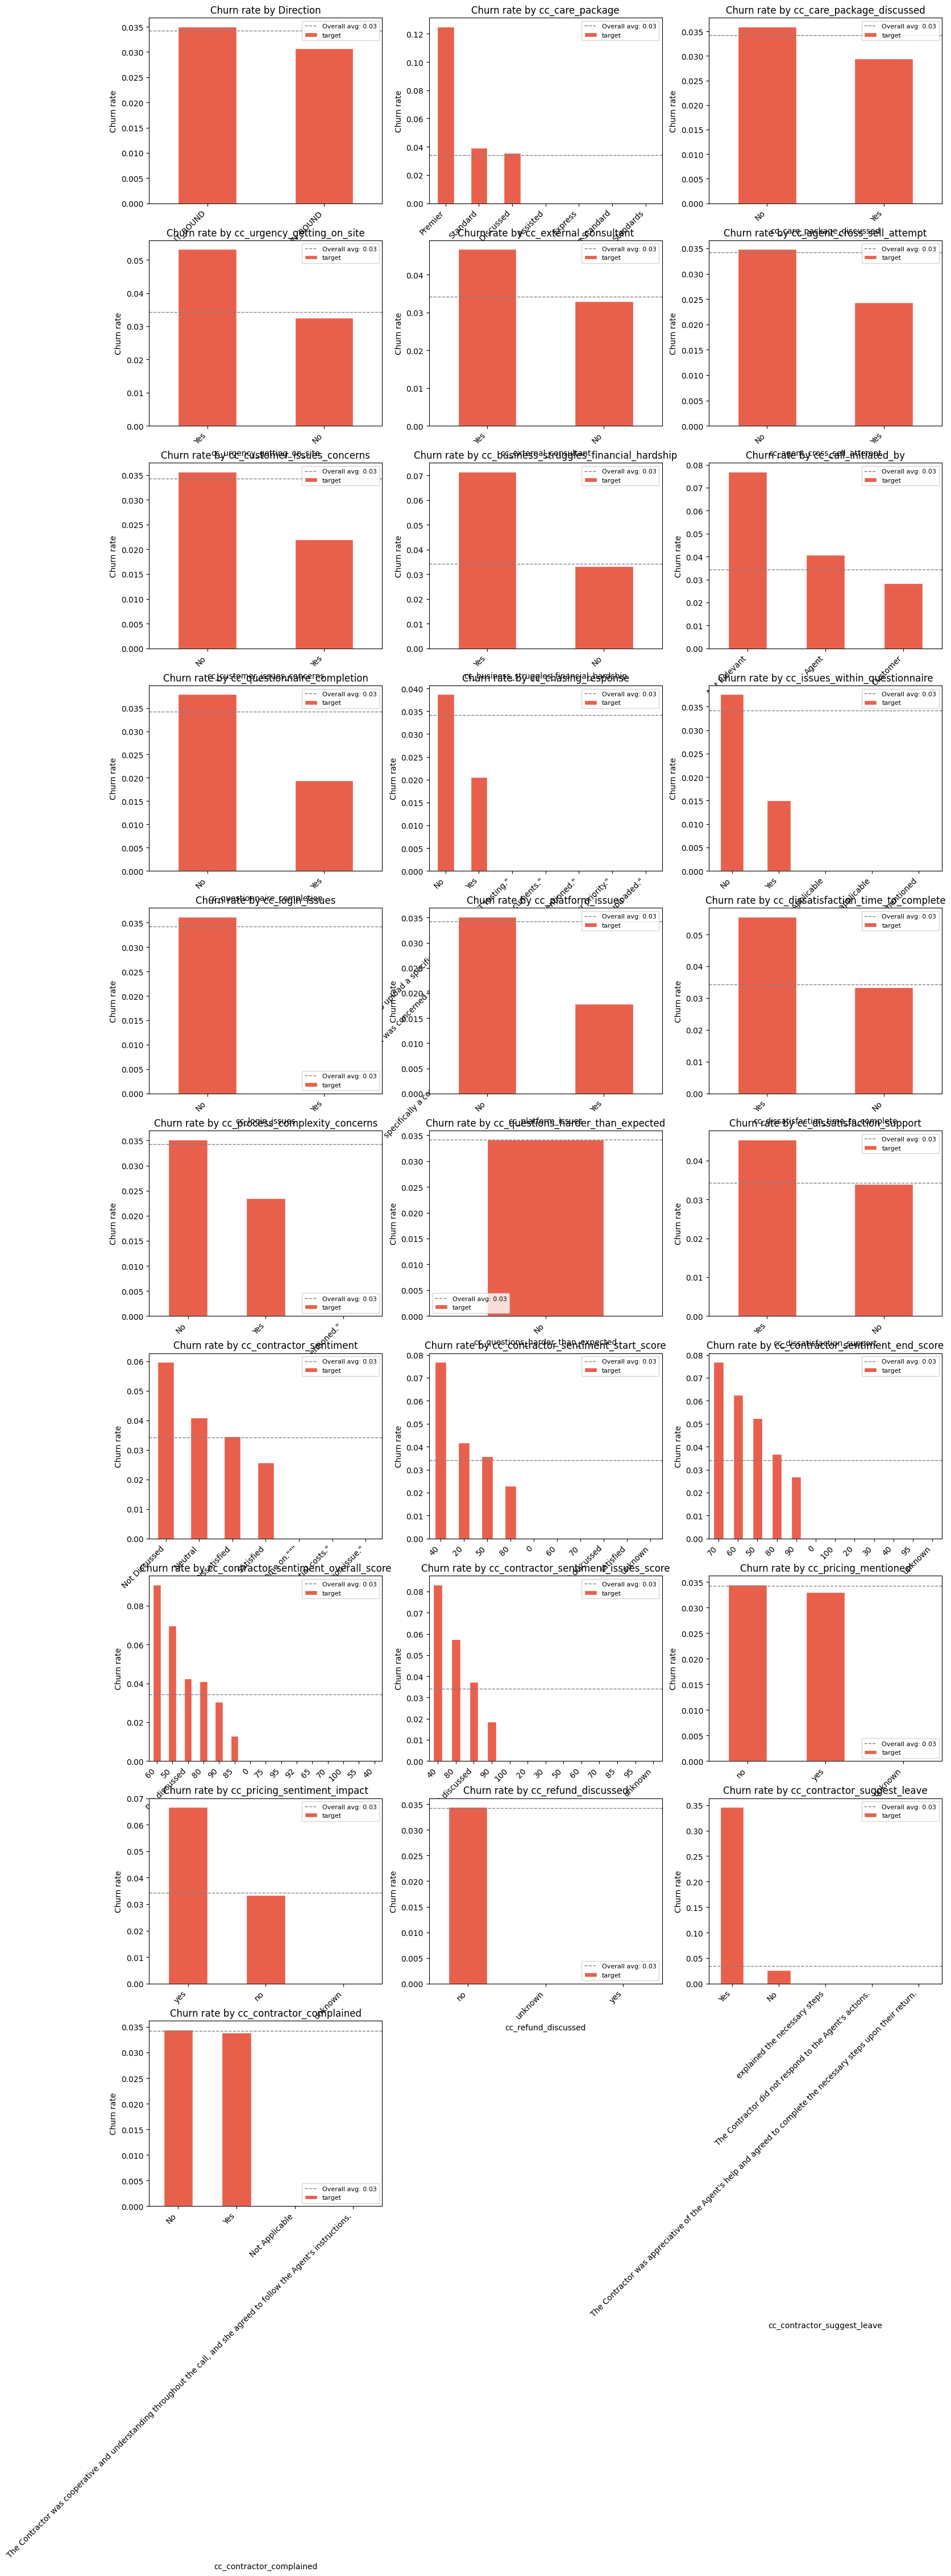

In [ ]:
# Churn rate bar chart per categorical column
cat_cols_biv = [c for c in cat_cols if df[c].nunique() <= 20]

if cat_cols_biv:
    n_cols_plot = 3
    n_rows_plot = math.ceil(len(cat_cols_biv) / n_cols_plot)

    plt.figure(figsize=(18, 5 * n_rows_plot))
    for i, col in enumerate(cat_cols_biv, 1):
        plt.subplot(n_rows_plot, n_cols_plot, i)
        churn_rate = (
            df.groupby(col, observed=True)['target']
            .mean()
            .sort_values(ascending=False)
            .head(15)
        )
        bars = churn_rate.plot(kind='bar', color='#E8604C', edgecolor='white', ax=plt.gca())
        plt.axhline(y=df['target'].mean(), color='gray', linestyle='--',
                    linewidth=1, label=f'Overall avg: {df["target"].mean():.2f}')
        plt.legend(fontsize=8)
        plt.title(f'Churn rate by {col}')
        plt.ylabel('Churn rate')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns with <= 20 unique values for bivariate plot')

In [ ]:
# Churn rate summary table for categorical columns
cat_churn_records = []
for col in cat_cols:
    churn_rate = df.groupby(col, observed=True)['target'].mean()
    count      = df.groupby(col, observed=True)['target'].count()
    for cat_val, rate in churn_rate.items():
        cat_churn_records.append({
            'feature':    col,
            'category':   cat_val,
            'churn_rate': round(rate, 3),
            'count':      count[cat_val]
        })

cat_churn_df = pd.DataFrame(cat_churn_records).sort_values('churn_rate', ascending=False)
print('Top 20 highest churn-rate categories:')
cat_churn_df.head(20)

Top 20 highest churn-rate categories:


,feature,category,churn_rate,count
124,cc_contractor_suggest_leave,Yes,0.346,26
6,cc_care_package,Premier,0.125,16
87,cc_contractor_sentiment_overall_score,60,0.091,22
101,cc_contractor_sentiment_issues_score,40,0.083,12
74,cc_contractor_sentiment_end_score,70,0.077,13
59,cc_contractor_sentiment_start_score,40,0.077,13
23,cc_call_initiated_by,Not Relevant,0.077,52
20,cc_business_struggles_financial_hardship,Yes,0.071,28
85,cc_contractor_sentiment_overall_score,50,0.070,43
116,cc_pricing_sentiment_impact,yes,0.067,30


---
## 7. Business Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

# ── Step 1: Convert required columns to numeric safely ───────────────────────
numeric_cols = [
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score',
    'cc_contractor_sentiment_overall_score',
    'Days_Before_Renewal'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Step 2: Sentiment change feature ─────────────────────────────────────────
if (
    'cc_contractor_sentiment_start_score' in df.columns and
    'cc_contractor_sentiment_end_score' in df.columns
):
    df['sentiment_change'] = (
        df['cc_contractor_sentiment_end_score']
        - df['cc_contractor_sentiment_start_score']
    )
    print('Created: sentiment_change (end - start)')

# ── Step 3: Negative sentiment flag ──────────────────────────────────────────
if 'cc_contractor_sentiment_overall_score' in df.columns:
    df['negative_sentiment_flag'] = (
        df['cc_contractor_sentiment_overall_score'] < 3
    ).astype(int)
    print('Created: negative_sentiment_flag')

# ── Step 4: Days before renewal bucket ───────────────────────────────────────
if 'Days_Before_Renewal' in df.columns:
    df['days_bucket'] = pd.cut(
        df['Days_Before_Renewal'],
        bins=[13, 21, 28, 35, 45],
        labels=['14-21d', '22-28d', '29-35d', '36-45d']
    )
    print('Created: days_bucket')

# ── Step 5: Example domain features (optional) ───────────────────────────────
# Uncomment if columns exist in your dataset

# if 'cc_pricing_mentioned' in df.columns and 'cc_contractor_complained' in df.columns:
#     df['pricing_and_complaint'] = (
#         (df['cc_pricing_mentioned'] == 1) &
#         (df['cc_contractor_complained'] == 1)
#     ).astype(int)
#     print('Created: pricing_and_complaint')

# if 'cc_urgency_getting_on_site' in df.columns:
#     df['high_urgency_flag'] = (df['cc_urgency_getting_on_site'] > 3).astype(int)
#     print('Created: high_urgency_flag')

# ── Step 6: Final dataset info ───────────────────────────────────────────────
print()
print('Current shape after feature engineering:', df.shape)

Created: sentiment_change (end - start)
Created: negative_sentiment_flag
Created: days_bucket

Current shape after feature engineering: (1023, 40)


In [ ]:
# Column diff — what was added vs backup
added   = df.columns.difference(df_backup.columns).tolist()
removed = df_backup.columns.difference(df.columns).tolist()

print('Columns added   :', added)
print('Columns removed :', removed)

Columns added   : ['days_bucket', 'negative_sentiment_flag', 'sentiment_change']
Columns removed : []


---
## 8. Correlation Analysis

### 8a. Feature vs Feature Correlation Heatmap

In [ ]:
# Collect all numerical cols including newly engineered ones
EXCLUDE_FROM_CORR = ['Co_Ref', 'Contact_ID', 'Call_Number', 'Call_Year']

num_cols_corr = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if col not in EXCLUDE_FROM_CORR
]

print(f'Columns included in correlation: {len(num_cols_corr)}')
print(num_cols_corr)

Columns included in correlation: 6
['cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score', 'Analysed_Call', 'Days_Before_Renewal', 'sentiment_change']


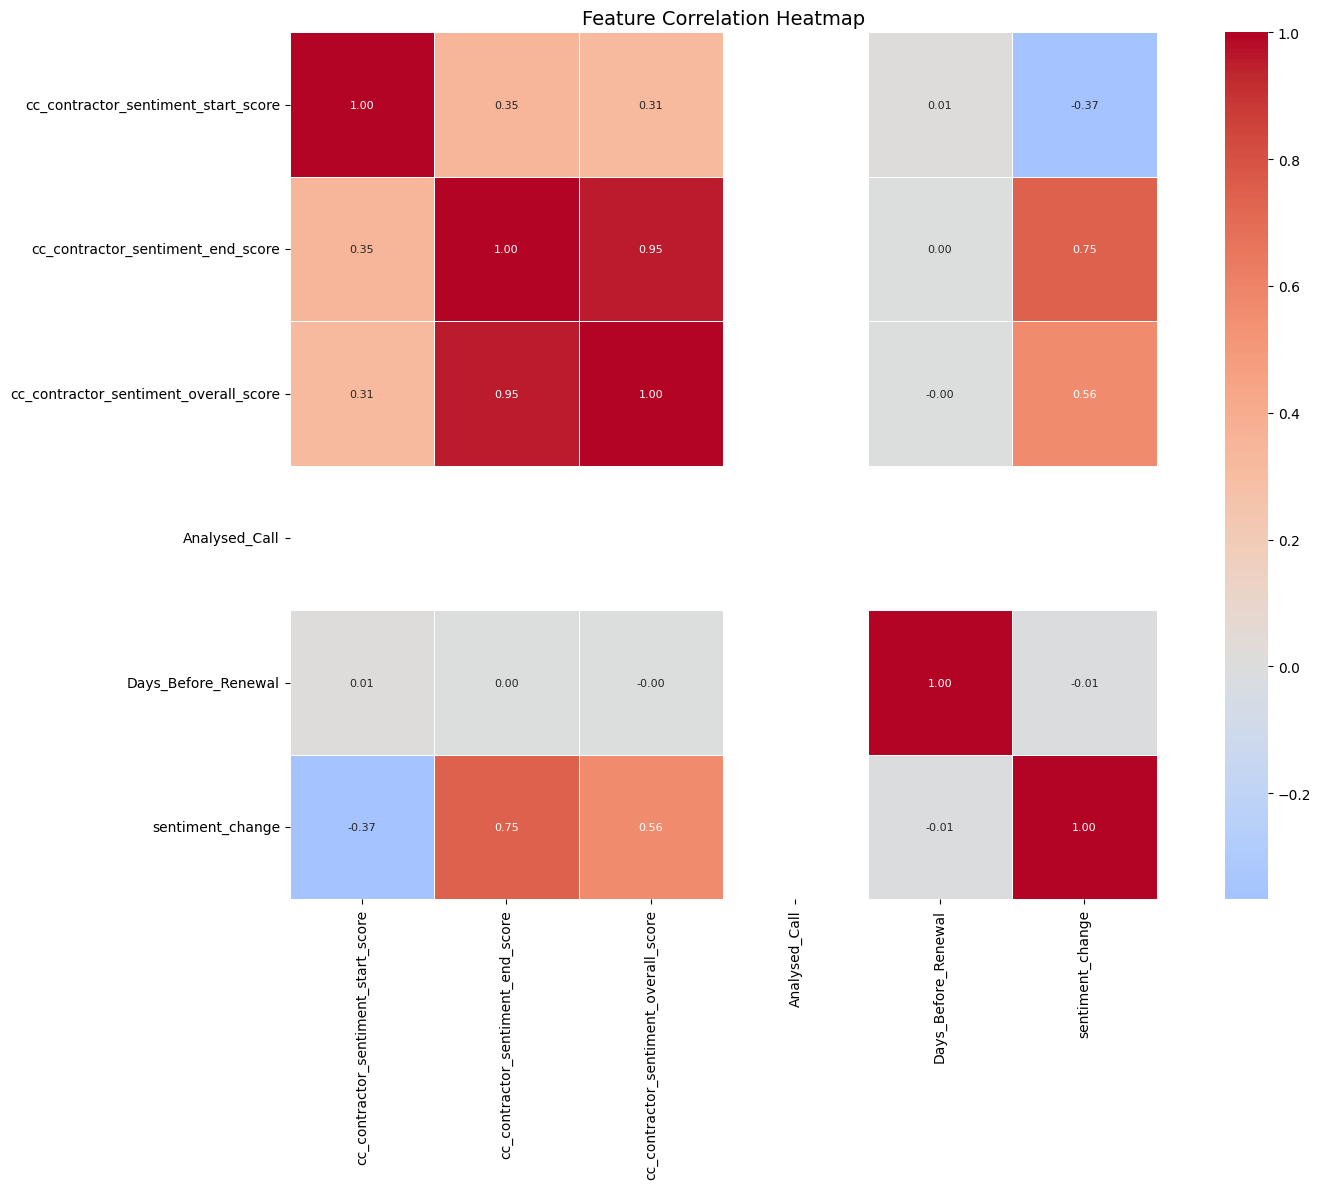

In [ ]:
corr_matrix = df[num_cols_corr].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Extract highly correlated pairs
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val  = corr_matrix.iloc[i, j]
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        if abs(val) >= threshold:
            high_corr_pairs.append((col1, col2, round(val, 3)))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    print(f'Highly correlated pairs (|r| >= {threshold}):')
    print(f'{"Feature A":<45} {"Feature B":<45} {"Corr":>6}')
    print('-' * 100)
    for a, b, v in high_corr_pairs:
        flag = '🔴 DROP ONE' if abs(v) >= 0.9 else '🟡 REVIEW'
        print(f'{a:<45} {b:<45} {v:>6}  {flag}')
else:
    print(f'✅ No pairs with correlation >= {threshold} found')

Highly correlated pairs (|r| >= 0.8):
Feature A                                     Feature B                                       Corr
----------------------------------------------------------------------------------------------------
cc_contractor_sentiment_end_score             cc_contractor_sentiment_overall_score          0.952  🔴 DROP ONE


In [ ]:
# TAKE DECISION ── drop one from each highly correlated pair
# Rule: keep the feature with stronger correlation to target
# Check churn_corr (next section) first, then come back here

# features_to_drop = []
# df.drop(columns=features_to_drop, inplace=True)
# num_cols_corr = [c for c in num_cols_corr if c not in features_to_drop]
# print('Dropped:', features_to_drop)

print('No columns dropped yet — review high_corr_pairs and churn_corr below first')

No columns dropped yet — review high_corr_pairs and churn_corr below first


### 8b. Feature vs Churn Correlation

In [ ]:
import numpy as np

# Ensure target is numeric
df['target'] = pd.to_numeric(df['target'])

# Make sure num_cols_corr includes only numeric columns + target
num_cols_corr = df.select_dtypes(include=[np.number]).columns

# Compute correlation matrix
corr_matrix = df[num_cols_corr].corr()

# Extract correlation with target
churn_corr = (
    corr_matrix['target']
    .drop('target')
    .sort_values(ascending=False)
)

print('🔴 Top 10 POSITIVELY correlated features (risk factors):')
print(churn_corr.head(10).round(4))

print()
print('🟢 Top 10 NEGATIVELY correlated features (protective factors):')
print(churn_corr.tail(10).round(4))

🔴 Top 10 POSITIVELY correlated features (risk factors):
negative_sentiment_flag                 -0.0118
cc_contractor_sentiment_start_score     -0.0260
sentiment_change                        -0.0284
cc_contractor_sentiment_overall_score   -0.0321
Days_Before_Renewal                     -0.0326
Call_Year                               -0.0427
cc_contractor_sentiment_end_score       -0.0461
Contact_ID                              -0.0678
Analysed_Call                               NaN
Name: target, dtype: float64

🟢 Top 10 NEGATIVELY correlated features (protective factors):
negative_sentiment_flag                 -0.0118
cc_contractor_sentiment_start_score     -0.0260
sentiment_change                        -0.0284
cc_contractor_sentiment_overall_score   -0.0321
Days_Before_Renewal                     -0.0326
Call_Year                               -0.0427
cc_contractor_sentiment_end_score       -0.0461
Contact_ID                              -0.0678
Analysed_Call                       

In [ ]:
print(corr_matrix)

                                       Contact_ID  \
Contact_ID                               1.000000   
cc_contractor_sentiment_start_score     -0.004383   
cc_contractor_sentiment_end_score       -0.003488   
cc_contractor_sentiment_overall_score   -0.047008   
Analysed_Call                                 NaN   
Call_Year                                0.509064   
Days_Before_Renewal                      0.040956   
target                                  -0.067789   
sentiment_change                        -0.005255   
negative_sentiment_flag                  0.027105   

                                       cc_contractor_sentiment_start_score  \
Contact_ID                                                       -0.004383   
cc_contractor_sentiment_start_score                               1.000000   
cc_contractor_sentiment_end_score                                 0.345994   
cc_contractor_sentiment_overall_score                             0.312739   
Analysed_Call             

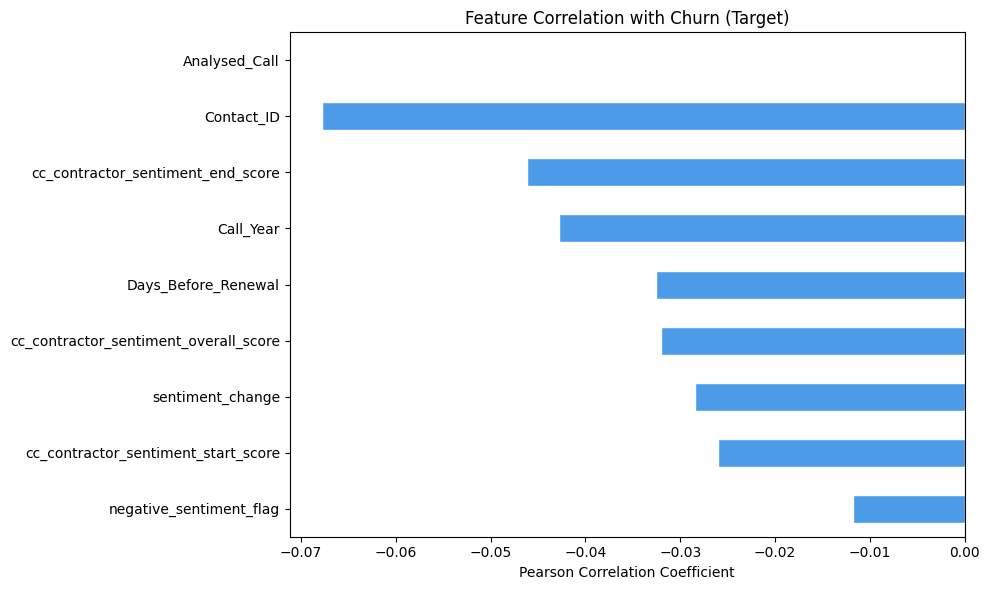

Red = positively correlated with churn (higher value → more churn)
Blue = negatively correlated with churn (higher value → less churn)


In [ ]:
# Horizontal bar chart — feature vs churn correlation
colors = ['#E8604C' if v > 0 else '#4C9BE8' for v in churn_corr.values]

plt.figure(figsize=(10, max(6, len(churn_corr) * 0.35)))
churn_corr.drop('target', errors='ignore').plot(
    kind='barh', color=colors, edgecolor='white'
)
plt.axvline(x=0, color='gray', linewidth=0.8)
plt.title('Feature Correlation with Churn (Target)')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Red = positively correlated with churn (higher value → more churn)')
print('Blue = negatively correlated with churn (higher value → less churn)')

### 8c. Point-Biserial Correlation (statistically robust vs binary target)

In [ ]:
# Point-biserial is more appropriate than Pearson when target is binary
# It also gives a p-value so you can check statistical significance

df_pb    = df.copy()
cols_pb  = [col for col in num_cols_corr if col != 'target']
df_pb[cols_pb] = df_pb[cols_pb].replace([np.inf, -np.inf], np.nan)
df_pb = df_pb.dropna(subset=['target'])

pb_results = []
for col in cols_pb:
    temp = df_pb[[col, 'target']].dropna()
    if len(temp) > 10:
        corr, pval = pointbiserialr(temp[col], temp['target'])
        pb_results.append({
            'feature':     col,
            'correlation': round(corr, 4),
            'p_value':     round(pval, 4),
            'significant': '✅ Yes' if pval < 0.05 else '❌ No'
        })

pb_df = pd.DataFrame(pb_results).sort_values('correlation', ascending=False)
print('🔹 Point-Biserial Correlation Results:')
pb_df

🔹 Point-Biserial Correlation Results:


C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:5546: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,feature,correlation,p_value,significant
8,negative_sentiment_flag,-0.0118,0.7064,❌ No
1,cc_contractor_sentiment_start_score,-0.0260,0.4072,❌ No
7,sentiment_change,-0.0284,0.3651,❌ No
3,cc_contractor_sentiment_overall_score,-0.0321,0.3423,❌ No
6,Days_Before_Renewal,-0.0326,0.2976,❌ No
5,Call_Year,-0.0427,0.1720,❌ No
2,cc_contractor_sentiment_end_score,-0.0461,0.1411,❌ No
0,Contact_ID,-0.0678,0.0302,✅ Yes
4,Analysed_Call,NaN,NaN,❌ No


In [ ]:
# Filter to statistically significant features only
important_features = pb_df[
    (pb_df['p_value'] < 0.05) & (pb_df['correlation'].abs() > 0.05)
].copy()

important_features['direction'] = important_features['correlation'].apply(
    lambda x: '🔴 Risk factor' if x > 0 else '🟢 Protective'
)

print(f'🔥 Statistically significant features (p < 0.05 and |corr| > 0.05): {len(important_features)}')
important_features.sort_values('correlation', ascending=False)

🔥 Statistically significant features (p < 0.05 and |corr| > 0.05): 1


,feature,correlation,p_value,significant,direction
0,Contact_ID,-0.0678,0.0302,✅ Yes,🟢 Protective


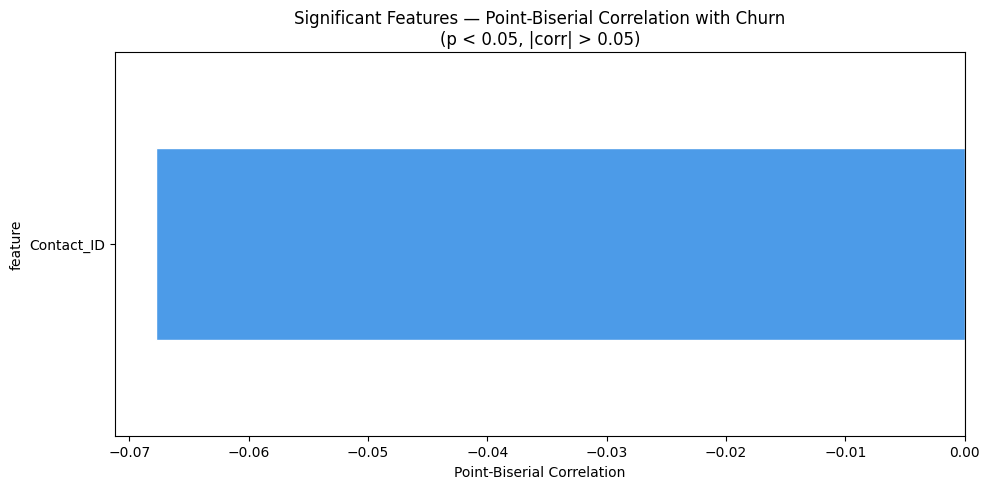

In [ ]:
# Plot only significant features
if len(important_features) > 0:
    sig = important_features.set_index('feature')['correlation'].sort_values()
    colors_sig = ['#E8604C' if v > 0 else '#4C9BE8' for v in sig.values]

    plt.figure(figsize=(10, max(5, len(sig) * 0.4)))
    sig.plot(kind='barh', color=colors_sig, edgecolor='white')
    plt.axvline(x=0, color='gray', linewidth=0.8)
    plt.title('Significant Features — Point-Biserial Correlation with Churn\n(p < 0.05, |corr| > 0.05)')
    plt.xlabel('Point-Biserial Correlation')
    plt.tight_layout()
    plt.show()
else:
    print('No significant features found at p < 0.05 and |corr| > 0.05')

---
## 9. Final Feature Selection Summary

In [ ]:
# Combine Pearson and Point-Biserial results into one summary table
pearson_series = churn_corr.rename('pearson_corr')
pb_series      = pb_df.set_index('feature')[['correlation', 'p_value', 'significant']]
pb_series.columns = ['pb_corr', 'p_value', 'significant']

feature_summary = pearson_series.to_frame().join(pb_series, how='outer')
feature_summary['abs_pb_corr'] = feature_summary['pb_corr'].abs()
feature_summary = feature_summary.sort_values('abs_pb_corr', ascending=False)

feature_summary['recommendation'] = feature_summary.apply(
    lambda row: (
        '✅ Keep — strong signal'    if (row['significant'] == '✅ Yes' and row['abs_pb_corr'] > 0.1) else
        '⚠️  Keep — weak signal'     if (row['significant'] == '✅ Yes' and row['abs_pb_corr'] <= 0.1) else
        '❌ Consider dropping'       if row['significant'] == '❌ No' else
        '❓ Review'
    ), axis=1
)

print('Feature selection summary (sorted by absolute point-biserial correlation):')
feature_summary[['pearson_corr', 'pb_corr', 'p_value', 'significant', 'recommendation']].round(4)

Feature selection summary (sorted by absolute point-biserial correlation):


,pearson_corr,pb_corr,p_value,significant,recommendation
Contact_ID,-0.0678,-0.0678,0.0302,✅ Yes,⚠️ Keep — weak signal
cc_contractor_sentiment_end_score,-0.0461,-0.0461,0.1411,❌ No,❌ Consider dropping
Call_Year,-0.0427,-0.0427,0.1720,❌ No,❌ Consider dropping
Days_Before_Renewal,-0.0326,-0.0326,0.2976,❌ No,❌ Consider dropping
cc_contractor_sentiment_overall_score,-0.0321,-0.0321,0.3423,❌ No,❌ Consider dropping
sentiment_change,-0.0284,-0.0284,0.3651,❌ No,❌ Consider dropping
cc_contractor_sentiment_start_score,-0.0260,-0.0260,0.4072,❌ No,❌ Consider dropping
negative_sentiment_flag,-0.0118,-0.0118,0.7064,❌ No,❌ Consider dropping
Analysed_Call,NaN,NaN,NaN,❌ No,❌ Consider dropping


In [ ]:
# TAKE DECISION ── drop features with no statistical significance
# weak_features = feature_summary[feature_summary['recommendation'] == '❌ Consider dropping'].index.tolist()
# df.drop(columns=[c for c in weak_features if c in df.columns], inplace=True)
# print('Dropped weak features:', weak_features)

print('No features dropped yet — finalise decisions above, then uncomment')

No features dropped yet — finalise decisions above, then uncomment


---
## 10. Final Summary & Save

In [ ]:
# Column tracking
added_cols   = df.columns.difference(df_backup.columns).tolist()
removed_cols = df_backup.columns.difference(df.columns).tolist()

print(f'Total columns now : {len(df.columns)}')
print(f'Added columns     : {added_cols}')
print(f'Removed columns   : {removed_cols}')
print()
print('Final target distribution:')
print(df['target'].value_counts())
print()
print('Final shape:', df.shape)

Total columns now : 40
Added columns     : ['days_bucket', 'negative_sentiment_flag', 'sentiment_change']
Removed columns   : []

Final target distribution:
target
0    988
1     35
Name: count, dtype: int64

Final shape: (1023, 40)


In [ ]:
# # Save EDA output
# os.makedirs('../../dataset/03_EDA/cc_calls', exist_ok=True)
df.to_csv('../../dataset/03_EDA/cc_calls/cc_calls_eda.csv', index=False)
print('✅ Saved to dataset/03_EDA/cc_calls/cc_calls_eda.csv')

✅ Saved to dataset/03_EDA/cc_calls/cc_calls_eda.csv
